In [1]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json

%matplotlib widget

def load_model(path):
    with open(path, "rb") as f:
        model = pickle.load(f)
    return model


In [4]:
# LOADING A MODEL

results_path = r"Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\gplvm_results\Bilat_R02_20251106_gplvm_decode_results_pre_sleep_fit_100binsdate-20260216.npz"
basePath  = os.path.dirname(results_path)
print(f"Loading model from: {results_path}\n (base path: {basePath})")


results = np.load(results_path)


print("Model and results loaded successfully.\n results keys:", results.keys())

Loading model from: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\gplvm_results\Bilat_R02_20251106_gplvm_decode_results_pre_sleep_fit_100binsdate-20260216.npz
 (base path: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\gplvm_results)
Model and results loaded successfully.
 results keys: KeysView(NpzFile 'Z:\\Homes\\voerom01\\Bilat_HPC\\Bilat_R02\\Bilat_R02_20251106\\gplvm_results\\Bilat_R02_20251106_gplvm_decode_results_pre_sleep_fit_100binsdate-20260216.npz' with keys: log_posterior_all, log_marginal_final, posterior_all, posterior_latent_marg, posterior_dynamics_marg...)


In [5]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
BASEPATH = r"Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
FIG_DIR = os.path.join(BASEPATH, "figures")
ANALYSIS_DIR = os.path.join(BASEPATH, "gplvm_results")

# probes, brain regions, and cell types
PROBES = [0, 1, 2, 3]                   # Probes to include in the analysis. There should be a corresponding basePath/baseName_imec{probe}.session.mat for each probe number
BRAIN_REGIONS = ['CA1']                 # Brain regions to include in the analysis (these are stored as tags in Cell Metrics, e.g., 'CA1', 'CA3', 'DG')
NEURON_TYPES = ['Pyramidal Cell']       # Neuron types to include in the analysis
EXCLUSION_TAGS = ['Bad']                # Tags for excluding neurons (e.g., 'Bad', 'Noise')


# Params for binning spike counts
WINDOW_SIZE = 0.01                      # s
STEP_SIZE   = 0.01                      # s
REFRACTORY_PERIOD_VIOLATIONS = 2        # percentage of allowed ISI less than 2ms

# Params for population burst detection
BURST_THRESHOLD = 3                 # z-scored population firing rate threshold for burst detection
BURST_BOUNDARY_THRESHOLD = 0        # z-scored population firing rate threshold for defining burst boundaries (start and end)
MIN_BURST_DURATION = 0.05           # minimum burst duration in seconds
MIN_INTERBURST_INTERVAL = 0.2      # minimum interval between bursts in seconds (will merge bursts that are closer than this)



# Filtering thresholds
MIN_TOTAL_SPIKES   = 500                # minimum total number of spikes across the session
MIN_MEAN_RATE_HZ   = 0.01               # minimum mean firing rate across the session (in Hz)
MIN_PRESENCE_RATIO = 0.50               # minimum fraction of time bins in which the neuron is active (spike count > 0)
N_TIME_BINS        = 100                # coarse bins for presence ratio


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
HEMISPHERE_DICT = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}


# Create figure directory and analysis directory if they don't exist
BASE_NAME = os.path.basename(BASEPATH)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

In [6]:
from scipy.io import loadmat

def mat_struct_to_dict(s):
    # for scipy with struct_as_record=False, squeeze_me=True
    return {name: getattr(s, name) for name in getattr(s, "_fieldnames", [])}

def compute_spike_counts(
    spike_times: list[np.ndarray],
    spike_clusters: np.ndarray,
    window_size: float = 1.0,
    sigma: float = 0,
    zscore: bool = False,
):
    """
    Compute spike counts using a sliding window approach from Cell Metrics data.
    
    This function processes spike times and cluster assignments from Kilosort/Phy2 which have been loaded from Cell Metrics, and computes spike counts within overlapping sliding windows.
    Optionally, Gaussian smoothing and z-scoring can be applied across time for each unit.

    Parameters
    ----------
    spike_times : list[np.ndarray]
        List of arrays of spike times for each unit.
    spike_clusters : np.ndarray
        Array of cluster IDs corresponding to each spike time.
    window_size : float, optional
        Size of the sliding window in seconds, default is 1.0.
    use_units : str, optional
        Filter for unit types to include:
        - 'all': Include all units
        - 'good': Include only good units
        - 'mua': Include only multi-unit activity
        - 'good/mua': Include both good units and multi-unit activity
        - 'noise': Include only noise units
        Default is 'all'.
    sigma : float, optional
        Standard deviation (in window steps) for Gaussian smoothing kernel. If 0 or None,
        no smoothing is applied. Default is 2.5.
    zscore : bool, optional
        Whether to z-score the spike counts over time for each unit, default is True.
    adj : str or None, optional
        Suffix for spike_times file (e.g., '_sec_adj'), consistent with your existing code.

    Returns
    -------
    spike_count_matrix : ndarray
        Matrix of spike counts (shape: num_units × num_windows).
    time_bins : ndarray
        Array of starting times for each window (seconds).
    units : ndarray
        Array of unit (cluster) IDs corresponding to rows of `spike_count_matrix`.

    Notes
    -----
    - Counts are raw spike counts per window before optional smoothing/z-scoring.
      To get rates later, you can divide by `window_size`.
    """
    step_size = window_size  # non-overlapping windows; adjust if you want overlap


    # Return early if no spikes
    if spike_times.size == 0:
        return (
            np.zeros((0, 0), dtype=np.float64),
            np.zeros((0,), dtype=np.float64),
            np.array([], dtype=int),
        )

    # Total duration of recording
    recording_duration = float(spike_times.max())
    if recording_duration < window_size:
        # No full window fits; return empty with units list
        units = np.unique(spike_clusters)
        return (
            np.zeros((len(units), 0), dtype=np.float64),
            np.zeros((0,), dtype=np.float64),
            units,
        )

    # Number of windows and their start times
    num_windows = 1 + int(np.floor((recording_duration - window_size) / step_size))
    time_bins = np.arange(num_windows, dtype=np.float64) * step_size  # window starts

    # Assign each spike to a window start index
    start_idx = np.floor(spike_times / step_size).astype(np.int64)
    valid = (start_idx >= 0) & (start_idx < num_windows)
    start_idx = start_idx[valid]
    spike_times_v = spike_times[valid]
    spike_clusters_v = spike_clusters[valid]

    # Guard against spikes that land in a start bin whose window would end before the spike
    win_end = (start_idx * step_size) + window_size
    valid2 = spike_times_v < win_end
    start_idx = start_idx[valid2]
    spike_clusters_v = spike_clusters_v[valid2]

    # Map units to row indices
    units = np.unique(spike_clusters_v)  # actual units present post-filter
    unit_to_row = {u: i for i, u in enumerate(units)}
    rows = np.fromiter(
        (unit_to_row[u] for u in spike_clusters_v),
        dtype=np.int64,
        count=spike_clusters_v.size,
    )

    # Accumulate counts: (unit, window) -> spike count
    spike_count_matrix = np.zeros((units.size, num_windows), dtype=np.float64)
    np.add.at(spike_count_matrix, (rows, start_idx), 1.0)

    # Optional smoothing (on counts)
    if sigma and sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        for r in range(spike_count_matrix.shape[0]):
            spike_count_matrix[r, :] = gaussian_filter1d(
                spike_count_matrix[r, :],
                sigma=sigma,
                mode='nearest',
            )

    # Optional z-score per unit
    if zscore:
        mean = spike_count_matrix.mean(axis=1, keepdims=True)
        std = spike_count_matrix.std(axis=1, keepdims=True)
        std[std == 0] = 1.0
        spike_count_matrix = (spike_count_matrix - mean) / std

    return spike_count_matrix, time_bins, units


def get_presence_ratio(
    est_counts_per_bin: np.ndarray,
    time_bins: np.ndarray,
    n_coarse_bins: int
) -> np.ndarray:
    """
    Compute presence ratio per unit using coarse time bins.
    A unit is 'present' in a coarse bin if its estimated spike count sum in that bin > 0.
    Vectorized via a (n_time x n_coarse_bins) binning matrix.
    """
    if time_bins.ndim != 1:
        raise ValueError("time_bins must be 1D (monotonic increasing).")
    if est_counts_per_bin.shape[1] != time_bins.size:
        raise ValueError("est_counts_per_bin columns must match len(time_bins).")

    t0 = time_bins[0]
    t1 = time_bins[-1] + (time_bins[1]-time_bins[0] if len(time_bins)>1 else 1.0)
    edges = np.linspace(t0, t1, n_coarse_bins + 1)
    # Map each fine time bin into a coarse bin index [0, n_coarse_bins-1]
    bin_idx = np.digitize(time_bins, edges, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, n_coarse_bins - 1)

    # Build a (n_time, n_coarse_bins) one-hot binning matrix (uint8 to save memory)
    n_time = time_bins.size
    B = np.zeros((n_time, n_coarse_bins), dtype=np.uint8)
    B[np.arange(n_time), bin_idx] = 1

    # Sum counts within each coarse bin for every unit: (n_units x n_time) @ (n_time x n_bins)
    coarse_sums = est_counts_per_bin @ B  # shape: (n_units, n_coarse_bins)

    # Presence if sum>0 in a coarse bin; ratio across bins
    presence = (coarse_sums > 0).mean(axis=1)
    return presence


def load_cell_metrics(cell_metrics_file, **kwargs):
    """
    Load and parse a CellExplorer `cell_metrics.cellinfo.mat` file.

    Parameters
    ----------
    cell_metrics_file : str
        Full path to the `.cell_metrics.cellinfo.mat` file
    
    **kwargs : dict, optional
        Additional options for loading and filtering:
        - verbose (bool): If True, print a summary of the loaded data.

    Returns
    -------
    dict
        Dictionary containing:
            - cellIDs : array-like
                CellExplorer cell IDs (1-indexed).
            - cluIDs : array-like
                Kilosort/Phy cluster IDs (0-indexed).
            - tags : dict
                Mapping of brain region name -> list of cellIDs in region.
            - spikeCount : array-like
                Total spike count per cell (indexed by cellID order).
            - putativeCellType : array-like
                Putative cell type labels per cell.
            - spikes : list of arrays
                Spike time arrays per cell.
            - shankID : array-like
                Shank ID per cell.
            - refractoryPeriodViolations : array-like
                Percentage of refractory period violations per cell.
            - SleepState : dict or None
                If present, a dictionary with keys for the sleep states and values of Nx2 double arrays of [start_time, end_time] for each detected episode of that state.

    Notes
    -----
    - `cellIDs` are 1-indexed (CellExplorer convention).
    - `cluIDs` are 0-indexed (Kilosort convention).
    - Returned arrays preserve ordering from the .mat file.
    """

    # unpacking kwargs
    verbose = kwargs.get("verbose", False)


    if not os.path.exists(cell_metrics_file):
        raise FileNotFoundError(f"Cell metrics file not found: {cell_metrics_file}")

    # Load .mat file
    raw = loadmat(cell_metrics_file, struct_as_record=False, squeeze_me=True)

    if "cell_metrics" not in raw:
        raise KeyError("`cell_metrics` structure not found in .mat file.")

    cell_metrics = mat_struct_to_dict(raw["cell_metrics"])

    # Extract fields (safely)
    cellIDs = cell_metrics.get("cellID")
    cluIDs = cell_metrics.get("cluID")
    spikeCount = cell_metrics.get("spikeCount")
    putativeCellType = cell_metrics.get("putativeCellType")
    shankID = cell_metrics.get("shankID")
    refractoryPeriodViolations = cell_metrics.get("refractoryPeriodViolation")
    general = cell_metrics.get("general")
    states = mat_struct_to_dict(general).get("states") if general is not None else None
    SleepState = mat_struct_to_dict(mat_struct_to_dict(states).get("SleepState")) if states is not None else None


    tags_raw = cell_metrics.get("tags")
    tags = mat_struct_to_dict(tags_raw) if tags_raw is not None else {}

    # extract spike times if available
    spikes_raw = cell_metrics.get("spikes")
    spikes = None
    if spikes_raw is not None:
        spikes_dict = mat_struct_to_dict(spikes_raw)
        spikes = spikes_dict.get("times")




    # ----------------------------
    # Verbose summary (clean + structured)
    # ----------------------------
    if verbose:
        n_cells = len(cellIDs) if cellIDs is not None else 0

        print("\n" + "=" * 60)
        print("Cell Metrics Summary")
        print("=" * 60)
        print(f"File: {cell_metrics_file}")
        print(f"Total cells: {n_cells}")

        # Brain regions
        if tags:
            print("\nBrain regions (tags):")
            for region, ids in tags.items():
                try:
                    count = len(ids)
                except TypeError:
                    count = 1
                print(f"  - {region:<15} : {count:>4} cells")
        else:
            print("\nBrain regions: None")

        # Sleep States
        if SleepState is not None:
            print("\nSleep states:")
            detected_states = SleepState.keys()
            for state in detected_states:
                print(f'    - {state}: {SleepState[state].shape}')
        else:
            print("\nSleep states: None")

        # Cell types
        if putativeCellType is not None:
            unique_types, counts = np.unique(putativeCellType, return_counts=True)
            print("\nPutative cell types:")
            for t, c in zip(unique_types, counts):
                print(f"  - {str(t):<20} : {c:>4} cells")
        else:
            print("\nPutative cell types: None")

        # Shank distribution
        if shankID is not None:
            unique_shanks, counts = np.unique(shankID, return_counts=True)
            print("\nShank distribution:")
            for s, c in zip(unique_shanks, counts):
                print(f"  - Shank {s:<5} : {c:>4} cells")

        print("=" * 60 + "\n")

    return {
        "cellIDs": cellIDs,
        "cluIDs": cluIDs,
        "tags": tags,
        "spikeCount": spikeCount,
        "refractoryPeriodViolations": refractoryPeriodViolations,
        "putativeCellType": putativeCellType,
        "spikes": spikes,
        "shankID": shankID,
        "SleepState": SleepState,
    }


def _intervals_from_boundaries(time_bins, boundaries, end_inclusive=True):
    """
    boundaries: list of (start_idx, end_idx)
    Returns list of dicts with start/end times and original indices.
    """
    tb = np.asarray(time_bins)
    out = []
    for k, (s, e) in enumerate(boundaries):
        if not end_inclusive:
            e = e - 1
        if e < s:
            continue
        out.append({
            "orig_k": k,
            "s_idx": s,
            "e_idx": e,
            "s_t": float(tb[s]),
            "e_t": float(tb[e]),
        })
    # Ensure sorted by start time
    out.sort(key=lambda d: d["s_t"])
    return out

def _to_indices(time_bins, s_t, e_t, end_inclusive=True):
    """
    Convert times back to indices on this probe's time_bins.
    We produce boundaries consistent with end_inclusive convention.
    """
    tb = np.asarray(time_bins)
    s_idx = int(np.searchsorted(tb, s_t, side="left"))
    # "right" gives first index > e_t, so inclusive end is -1
    e_idx_inclusive = int(np.searchsorted(tb, e_t, side="right") - 1)

    s_idx = max(0, min(s_idx, len(tb) - 1))
    e_idx_inclusive = max(0, min(e_idx_inclusive, len(tb) - 1))
    if e_idx_inclusive < s_idx:
        e_idx_inclusive = s_idx

    if end_inclusive:
        return s_idx, e_idx_inclusive
    else:
        # exclusive end is inclusive+1 (capped at len(tb))
        e_idx_exclusive = min(e_idx_inclusive + 1, len(tb))
        return s_idx, e_idx_exclusive

def merge_overlapping_bursts_two_probes(data_dict, probeA, probeB, end_inclusive=True, strict_overlap=True):
    """
    Forms connected overlap groups across probeA and probeB, merges bursts within each group per probe.
    Returns:
      mergedA_boundaries, mergedB_boundaries, groups
    where groups is list of dicts with merged times and membership.
    """
    A = _intervals_from_boundaries(data_dict[probeA]["time_bins"],
                                   data_dict[probeA].get("burst_boundaries", []),
                                   end_inclusive=end_inclusive)
    B = _intervals_from_boundaries(data_dict[probeB]["time_bins"],
                                   data_dict[probeB].get("burst_boundaries", []),
                                   end_inclusive=end_inclusive)

    # Two-pointer sweep to build groups of connected overlaps.
    i = j = 0
    groups = []

    # helper overlap predicate
    def overlaps(a_s, a_e, b_s, b_e):
        if strict_overlap:
            return (a_s < b_e) and (b_s < a_e)  # positive-length overlap in time
        else:
            return (a_s <= b_e) and (b_s <= a_e)  # touch counts as overlap

    # We’ll build groups as time-connected components in the combined interval graph.
    # Start from earliest next interval, then expand group window while intervals overlap that window.
    combined = [(d["s_t"], d["e_t"], "A", d) for d in A] + [(d["s_t"], d["e_t"], "B", d) for d in B]
    combined.sort(key=lambda x: x[0])

    k = 0
    while k < len(combined):
        # start a new group window
        g_start = combined[k][0]
        g_end   = combined[k][1]
        membersA = []
        membersB = []

        # grow group while next interval overlaps current group window
        kk = k
        while kk < len(combined):
            s_t, e_t, side, d = combined[kk]
            # decide overlap with current window
            if strict_overlap:
                if s_t >= g_end:  # no overlap; because strict
                    break
            else:
                if s_t > g_end:
                    break

            # include interval
            if side == "A":
                membersA.append(d)
            else:
                membersB.append(d)

            # expand window end if needed
            if e_t > g_end:
                g_end = e_t
            kk += 1

        # Within this time-window group, we may have included intervals that touch the window
        # but don't actually overlap across probes (e.g., A-only cluster). That's okay—those become "local".
        groups.append({
            "g_start": g_start,
            "g_end": g_end,
            "A_members": membersA,
            "B_members": membersB,
        })
        k = kk

    # Merge within each group per probe
    mergedA = []
    mergedB = []
    merged_groups = []

    for g in groups:
        A_mem = g["A_members"]
        B_mem = g["B_members"]

        A_merged = None
        B_merged = None

        if A_mem:
            A_merged = (min(d["s_t"] for d in A_mem), max(d["e_t"] for d in A_mem))
            mergedA.append(A_merged)
        if B_mem:
            B_merged = (min(d["s_t"] for d in B_mem), max(d["e_t"] for d in B_mem))
            mergedB.append(B_merged)

        merged_groups.append({
            "A_time": A_merged,
            "B_time": B_merged,
            "A_orig_indices": [d["orig_k"] for d in A_mem],
            "B_orig_indices": [d["orig_k"] for d in B_mem],
        })

    # Convert merged times back to boundaries (indices) on each probe's own time_bins
    mergedA_boundaries = []
    for s_t, e_t in mergedA:
        mergedA_boundaries.append(_to_indices(data_dict[probeA]["time_bins"], s_t, e_t, end_inclusive=end_inclusive))

    mergedB_boundaries = []
    for s_t, e_t in mergedB:
        mergedB_boundaries.append(_to_indices(data_dict[probeB]["time_bins"], s_t, e_t, end_inclusive=end_inclusive))

    return mergedA_boundaries, mergedB_boundaries, merged_groups


def detect_population_bursts(zsmoothed_mua, **kwargs):

    # unpacking kwargs
    BURST_THRESHOLD = kwargs.get("BURST_THRESHOLD", 3)
    BURST_BOUNDARY_THRESHOLD = kwargs.get("BURST_BOUNDARY_THRESHOLD", 0)
    MIN_BURST_DURATION = kwargs.get("MIN_BURST_DURATION", 0.05)
    MIN_INTERBURST_INTERVAL = kwargs.get("MIN_INTERBURST_INTERVAL", 0.25)


    burst_mask = zsmoothed_mua > BURST_THRESHOLD
    burst_mask = np.concatenate(([False], burst_mask, [False]))

    burst_starts = np.where(np.diff(burst_mask.astype(int)) == 1)[0]
    burst_ends   = np.where(np.diff(burst_mask.astype(int)) == -1)[0]  # inclusive end

    # merge bursts separated by short gaps
    if len(burst_starts) >= 2:
        gap_bins = burst_starts[1:] - burst_ends[:-1] - 1
        merge_mask = (gap_bins * STEP_SIZE) < MIN_INTERBURST_INTERVAL

        burst_starts = np.delete(burst_starts, np.where(merge_mask)[0] + 1)
        burst_ends   = np.delete(burst_ends,   np.where(merge_mask)[0])

    # expand boundaries using boundary threshold
    burst_boundaries = []
    n = len(zsmoothed_mua)

    for start, end in zip(burst_starts, burst_ends):
        while start > 0 and zsmoothed_mua[start - 1] > BURST_BOUNDARY_THRESHOLD:
            start -= 1
        while end < n - 1 and zsmoothed_mua[end + 1] > BURST_BOUNDARY_THRESHOLD:
            end += 1
        burst_boundaries.append((start, end))

    burst_starts = np.array([b[0] for b in burst_boundaries])
    burst_ends = np.array([b[1] for b in burst_boundaries])

    # duration filter (inclusive ends)
    burst_durations = (burst_ends - burst_starts + 1) * STEP_SIZE
    valid = burst_durations >= MIN_BURST_DURATION
    burst_starts = burst_starts[valid]
    burst_ends   = burst_ends[valid]

    burst_boundaries = [(s, e) for s, e in zip(burst_starts, burst_ends)]
    return burst_boundaries



In [7]:
# ------------------------ Load the data from cell metrics file ------------------------
data_dict = {}
for probe in PROBES:
    cell_metrics_file = os.path.join(BASEPATH, f'{BASE_NAME}_imec{probe}.cell_metrics.cellinfo_spikes_adjusted.mat')
    data_dict[probe] = load_cell_metrics(cell_metrics_file, verbose=True)




Cell Metrics Summary
File: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\Bilat_R02_20251106_imec0.cell_metrics.cellinfo_spikes_adjusted.mat
Total cells: 173

Brain regions (tags):
  - CA1             :  152 cells
  - Th              :    0 cells
  - Noise           :    0 cells
  - Good            :   11 cells
  - Bad             :    9 cells

Sleep states:
    - WAKEstate: (47, 2)
    - NREMstate: (46, 2)
    - REMstate: (31, 2)

Putative cell types:
  - Narrow Interneuron   :   20 cells
  - Pyramidal Cell       :  149 cells
  - Wide Interneuron     :    4 cells

Shank distribution:
  - Shank 1     :   51 cells
  - Shank 2     :   55 cells
  - Shank 3     :   13 cells
  - Shank 4     :   54 cells


Cell Metrics Summary
File: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\Bilat_R02_20251106_imec1.cell_metrics.cellinfo_spikes_adjusted.mat
Total cells: 108

Brain regions (tags):
  - CA1             :  108 cells
  - Bad             :    1 cells

Sleep states:
    - W

In [8]:
# ------------------------ Compute spike counts and presence ratio and filter units ------------------------
for probe in PROBES:

    # loading spike times and cluster IDs
    spikes = data_dict[probe]['spikes']
    spike_clusters = np.asarray(data_dict[probe]['cluIDs'])

    # Concatenate all spike times and corresponding cluster IDs into flat arrays
    all_spike_times = np.concatenate([np.asarray(s).ravel() for s in spikes]) if spikes is not None else np.array([])
    all_clusters = np.repeat(spike_clusters, [len(s) for s in spikes]) if spikes is not None else np.array([])


    if spikes is None or spike_clusters is None:
        print(f"Probe {probe}: No spike data found. Skipping.")
        continue

    # Compute spike counts per window
    spike_count_matrix, time_bins, units = compute_spike_counts(
        spike_times=all_spike_times,
        spike_clusters=all_clusters,
        window_size=WINDOW_SIZE,
        sigma=0,
        zscore=False,
    )

    # Compute presence ratio per unit
    presence_ratio = get_presence_ratio(
        est_counts_per_bin=spike_count_matrix,
        time_bins=time_bins,
        n_coarse_bins=N_TIME_BINS
    )

    # filter units based on presence ratio and total spike count
    total_spikes_per_unit = spike_count_matrix.sum(axis=1) * (STEP_SIZE / WINDOW_SIZE)  # convert back to total spikes
    valid_units = (total_spikes_per_unit >= MIN_TOTAL_SPIKES) & (presence_ratio >= MIN_PRESENCE_RATIO)
    valid_units &= (total_spikes_per_unit / (time_bins[-1] + STEP_SIZE) >= MIN_MEAN_RATE_HZ)  # mean rate filter

    # filter out bad tags
    tags = data_dict[probe]['tags']
    if tags:
        for bad_tag in EXCLUSION_TAGS:
            if bad_tag in tags:
                bad_unit_ids = tags[bad_tag]
                if isinstance(bad_unit_ids, (list, np.ndarray)):
                    bad_unit_ids = set(bad_unit_ids)
                    valid_units &= ~np.isin(units, list(bad_unit_ids))
                else:
                    print(f"Warning: Tag '{bad_tag}' in probe {probe} has non-list value. Skipping tag filtering for this tag.")
    else:
        print(f"Probe {probe}: No tags found for filtering.")


    # filtering out units with too many refractory period violations
    refractory_violations = data_dict[probe].get('refractoryPeriodViolations')
    if refractory_violations is not None:
        refractory_violations = np.asarray(refractory_violations)
        if refractory_violations.size == len(units):
            valid_units &= (refractory_violations <= REFRACTORY_PERIOD_VIOLATIONS)
        else:
            print(f"Warning: Length of refractoryPeriodViolations does not match number of units for probe {probe}. Skipping refractory period filtering.")

    print(f"Probe {probe}: {valid_units.sum()} valid units out of {len(units)} total units after filtering.")

    # Store results back in the data dictionary
    data_dict[probe]['spike_count_matrix'] = spike_count_matrix
    data_dict[probe]['time_bins'] = time_bins
    data_dict[probe]['units'] = units
    data_dict[probe]['presence_ratio'] = presence_ratio
    data_dict[probe]['valid_units'] = valid_units           # boolean mask of valid units after filtering to use for the decoding analysis
    data_dict[probe]['bad_unit_indices'] = bad_unit_ids     # these are just the unit IDs that were tagged as bad, they will not be used for any further analysis

Probe 0: 59 valid units out of 173 total units after filtering.
Probe 1: 26 valid units out of 108 total units after filtering.
Probe 2: 232 valid units out of 405 total units after filtering.
Probe 3: 181 valid units out of 397 total units after filtering.


In [9]:
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

# ------------------------- compute the MUA for each hemisphere -------------------------
nTimeBins = len(time_bins)

for probe in PROBES:
    print(f"\nComputing MUA for probe {probe}...")
    shanks = data_dict[probe]['shankID']
    spike_count_matrix = data_dict[probe]['spike_count_matrix']
    bad_unit_ids = data_dict[probe].get('bad_unit_indices', [])

    probe_mua = np.zeros((len(np.unique(shanks)), nTimeBins))
    for shank in np.unique(shanks):
        shank_units = np.where(shanks == shank)[0]
        region_units = data_dict[probe]['tags'].get(BRAIN_REGIONS[0], [])
        shank_units_keep = np.intersect1d(shank_units, region_units)  # only include units in the specified brain region
        shank_units_keep = np.setdiff1d(shank_units_keep, bad_unit_ids)  # exclude bad units
        print(f"    Shank {shank}: {len(shank_units_keep)} / {len(shank_units)} units included in MUA calculation after filtering.")
        probe_mua[shank - 1, :] = spike_count_matrix[shank_units_keep, :].sum(axis=0) / len(shank_units_keep)  # average MUA across units in the shank
    probe_mua = np.mean(probe_mua, axis=0)  # average MUA across shanks for the hemisphere
    zmoothed_mua = zscore(gaussian_filter1d(probe_mua, sigma=1))

    # detecting population bursts based on the MUA

    
    data_dict[probe]['mua'] = probe_mua
    data_dict[probe]['zmoothed_mua'] = zmoothed_mua


Computing MUA for probe 0...
    Shank 1: 31 / 51 units included in MUA calculation after filtering.
    Shank 2: 55 / 55 units included in MUA calculation after filtering.
    Shank 3: 13 / 13 units included in MUA calculation after filtering.
    Shank 4: 52 / 54 units included in MUA calculation after filtering.

Computing MUA for probe 1...
    Shank 1: 32 / 32 units included in MUA calculation after filtering.
    Shank 2: 27 / 27 units included in MUA calculation after filtering.
    Shank 3: 26 / 27 units included in MUA calculation after filtering.
    Shank 4: 21 / 22 units included in MUA calculation after filtering.

Computing MUA for probe 2...
    Shank 1: 82 / 85 units included in MUA calculation after filtering.
    Shank 2: 79 / 82 units included in MUA calculation after filtering.
    Shank 3: 37 / 41 units included in MUA calculation after filtering.
    Shank 4: 131 / 197 units included in MUA calculation after filtering.

Computing MUA for probe 3...
    Shank 1: 7

In [10]:
burst_detection_kwargs = {
    "BURST_THRESHOLD": BURST_THRESHOLD,
    "BURST_BOUNDARY_THRESHOLD": BURST_BOUNDARY_THRESHOLD,
    "MIN_BURST_DURATION": MIN_BURST_DURATION,
    "MIN_INTERBURST_INTERVAL": MIN_INTERBURST_INTERVAL,
}
for probe in PROBES:
    zsmoothed_mua = data_dict[probe]["zmoothed_mua"]
    burst_boundaries = detect_population_bursts(zsmoothed_mua, **burst_detection_kwargs)
    print(f"Probe {probe}: Detected {len(burst_boundaries)} population bursts after filtering.")
    data_dict[probe]["burst_boundaries"] = burst_boundaries

# detecting population bust events on a total mua across all probes
total_mua = np.zeros_like(data_dict[PROBES[0]]["mua"])
for probe in PROBES:
    total_mua += data_dict[probe]["mua"]
total_zmua = zscore(gaussian_filter1d(total_mua / len(PROBES), sigma=1))

# detecting population bursts based on the total MUA
total_burst_boundaries = detect_population_bursts(total_zmua, **burst_detection_kwargs)
print(f"Total MUA: Detected {len(total_burst_boundaries)} population bursts after filtering.")


    

Probe 0: Detected 4247 population bursts after filtering.
Probe 1: Detected 4235 population bursts after filtering.
Probe 2: Detected 3774 population bursts after filtering.
Probe 3: Detected 4601 population bursts after filtering.
Total MUA: Detected 4173 population bursts after filtering.


In [11]:
SYNCHRONY_THRESHOLD = 0.001  # seconds
end_inclusive = True



for hemi in ["R", "L"]:
    probes = [p for p in PROBES if HEMISPHERE_DICT.get(p) == hemi]
    if len(probes) != 2:
        raise ValueError(f"Expected 2 probes in hemisphere {hemi}, found {len(probes)}: {probes}")

    pA, pB = probes

    A_merged, B_merged, groups = merge_overlapping_bursts_two_probes(
        data_dict, pA, pB,
        end_inclusive=end_inclusive,
        strict_overlap=True
    )

    data_dict[pA]["burst_boundaries_merged"] = A_merged
    data_dict[pB]["burst_boundaries_merged"] = B_merged
    data_dict[(pA, pB, "merged_groups")] = groups  # optional bookkeeping

for hemi in ["R", "L"]:
    use_probes = [p for p in PROBES if HEMISPHERE_DICT.get(p) == hemi]

    # Basic guard: you assumed exactly 2 probes per hemisphere
    if len(use_probes) != 2:
        raise ValueError(f"Expected 2 probes in hemisphere {hemi}, found {len(use_probes)}: {use_probes}")

    for probe in use_probes:
        burst_boundaries = data_dict[probe]["burst_boundaries_merged"]
        other_probe = next(p for p in use_probes if p != probe)
        other_bursts = data_dict[other_probe]["burst_boundaries_merged"]

        print(f"\nClassifying population bursts for probe {probe}:")

        # initialize subtype list for this probe
        data_dict[probe]["burst_subtype"] = []

        # helper refs
        t_probe = data_dict[probe]["time_bins"]
        t_other = data_dict[other_probe]["time_bins"]

        for (start_idx, end_idx) in burst_boundaries:
            # Assumption: end_idx is INCLUSIVE. If end_idx is EXCLUSIVE, use end_idx-1 below.
            b0 = t_probe[start_idx]
            b1 = t_probe[end_idx]

            overlap = False
            ob0_time = None
            ob1_time = None

            for (ob0, ob1) in other_bursts:
                # Assumption: ob1 is INCLUSIVE. If EXCLUSIVE, use ob1-1 below.
                ob0_t = t_other[ob0]
                ob1_t = t_other[ob1]

                # interval overlap check
                if (b0 <= ob1_t) and (ob0_t <= b1):
                    overlap = True
                    ob0_time, ob1_time = ob0_t, ob1_t
                    break

            if not overlap:
                data_dict[probe]["burst_subtype"].append("local")
                continue

            # classify relative timing
            start_diff = b0 - ob0_time   # + means this probe starts later
            end_diff   = b1 - ob1_time   # + means this probe ends later

            if start_diff == 0:
                subtype = "synchronous"
            elif start_diff < 0:
                subtype = "leading"
            elif start_diff > 0:
                subtype = "lagging"
            else:
                subtype = "overlapping"  # instead of "error"

            data_dict[probe]["burst_subtype"].append(subtype)
        print(f"Burst classification complete:\n    synchronous events: {data_dict[probe]['burst_subtype'].count('synchronous')}\n    leading events: {data_dict[probe]['burst_subtype'].count('leading')}\n    lagging events: {data_dict[probe]['burst_subtype'].count('lagging')}\n    local events: {data_dict[probe]['burst_subtype'].count('local')}\n    overlapping events: {data_dict[probe]['burst_subtype'].count('overlapping')}")



Classifying population bursts for probe 2:
Burst classification complete:
    synchronous events: 618
    leading events: 712
    lagging events: 1623
    local events: 781
    overlapping events: 0

Classifying population bursts for probe 3:
Burst classification complete:
    synchronous events: 618
    leading events: 1622
    lagging events: 713
    local events: 1594
    overlapping events: 0

Classifying population bursts for probe 0:
Burst classification complete:
    synchronous events: 776
    leading events: 1293
    lagging events: 1318
    local events: 803
    overlapping events: 0

Classifying population bursts for probe 1:
Burst classification complete:
    synchronous events: 776
    leading events: 1318
    lagging events: 1293
    local events: 805
    overlapping events: 0


Tracking keys: ('timestamps', 'frameCount', 'position', 'orientation', 'errorPerMarker', 'substructnames', 'rotation_type', 'acquisition_system', 'description')
Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


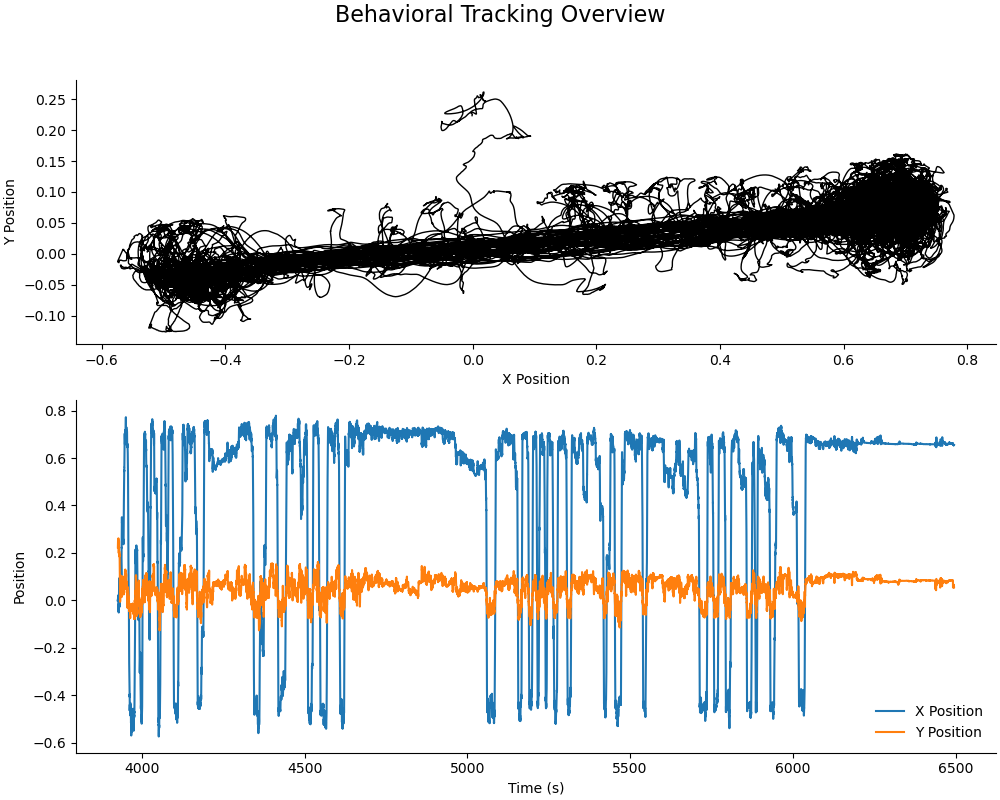

In [12]:
tracking_file = os.path.join(BASEPATH, f"{BASE_NAME}_imec0.tracking.behavior.mat")
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']
print("Tracking keys:", tracking.dtype.names)

tracking_timestamps = tracking['timestamps'].item()
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]





fig, axs = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0].plot(x, y, color="black", linewidth=1)
axs[0].set_xlabel("X Position")
axs[0].set_ylabel("Y Position")
axs[0].set_aspect("equal")  # preserves spatial geometry
sns.despine(ax=axs[0])

# --- Bottom: Position over time ---
axs[1].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Position")
axs[1].legend(frameon=False)
sns.despine(ax=axs[1])

fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()


In [13]:
print(results.keys())
posterior = results['posterior_latent_marg']  # shape: (n_time_bins, n_latent_bins)
print(posterior.shape)

KeysView(NpzFile 'Z:\\Homes\\voerom01\\Bilat_HPC\\Bilat_R02\\Bilat_R02_20251106\\gplvm_results\\Bilat_R02_20251106_gplvm_decode_results_pre_sleep_fit_100binsdate-20260216.npz' with keys: log_posterior_all, log_marginal_final, posterior_all, posterior_latent_marg, posterior_dynamics_marg...)
(1052094, 100)


In [14]:
# discretize the position into 25 bins
N_LATENT_BINS = posterior.shape[1]
pos = x
pos_bins = np.linspace(pos.min(), pos.max(), N_LATENT_BINS + 1)
pos_bin_centers = (pos_bins[:-1] + pos_bins[1:]) / 2
pos_bin_indices = np.digitize(pos, pos_bins) - 1  # bin indices for each time point, 0-indexed
pos_bin_indices = np.clip(pos_bin_indices, 0, N_LATENT_BINS - 1)  # ensure indices are within valid range
pos_bin_indices = N_LATENT_BINS - 1 - pos_bin_indices # reverse order to match the latent bins

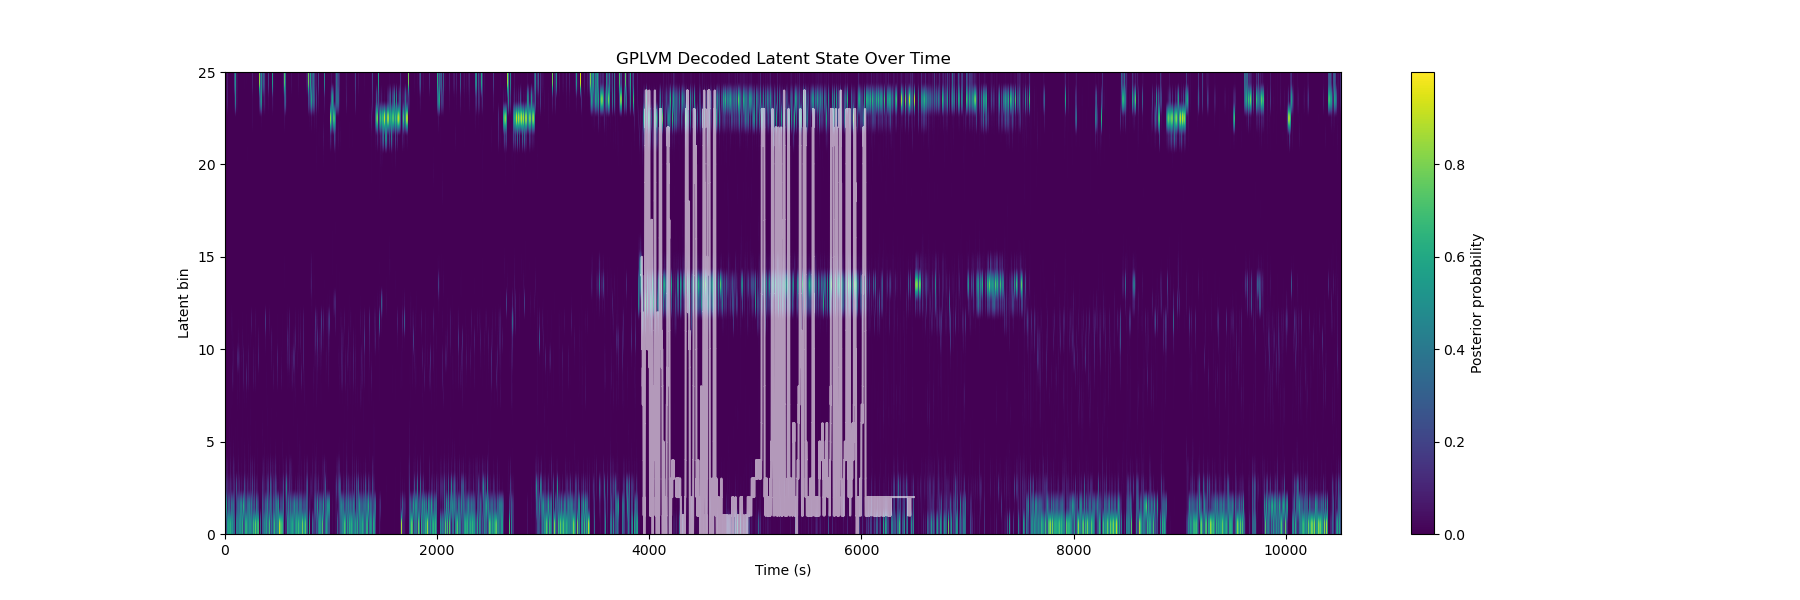

In [13]:
plt.figure(figsize=(18, 6))
plt.imshow(posterior.T, aspect='auto', origin='lower', cmap='viridis', extent=[time_bins[0], time_bins[-1], 0, N_LATENT_BINS])
plt.plot(tracking_timestamps, pos_bin_indices, label="X Position", color="white", linewidth=1.5, alpha = 0.6)
plt.colorbar(label='Posterior probability')
plt.xlabel('Time (s)')
plt.ylabel('Latent bin')
plt.title('GPLVM Decoded Latent State Over Time')
plt.show()

In [15]:
print(posterior.shape)

(1052094, 100)


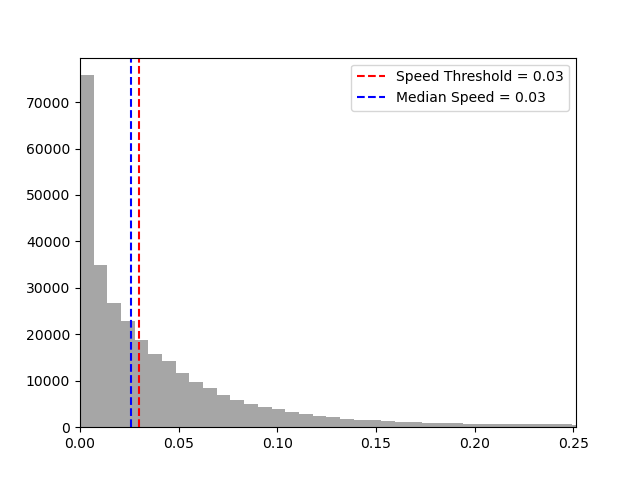

use_posterior shape: (1052094, 100), pos_bin_indices shape: (308232,)


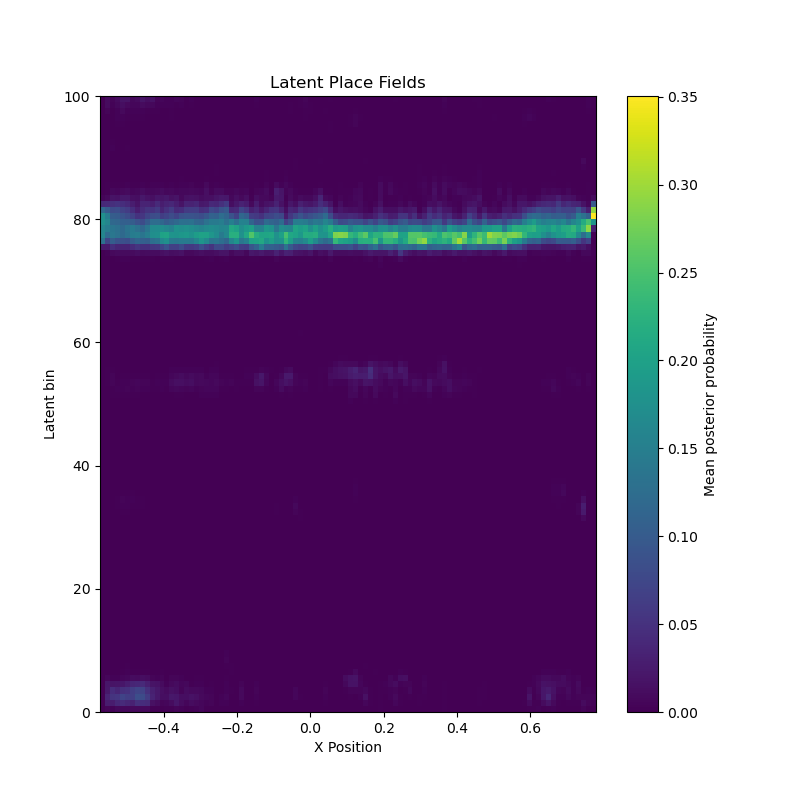

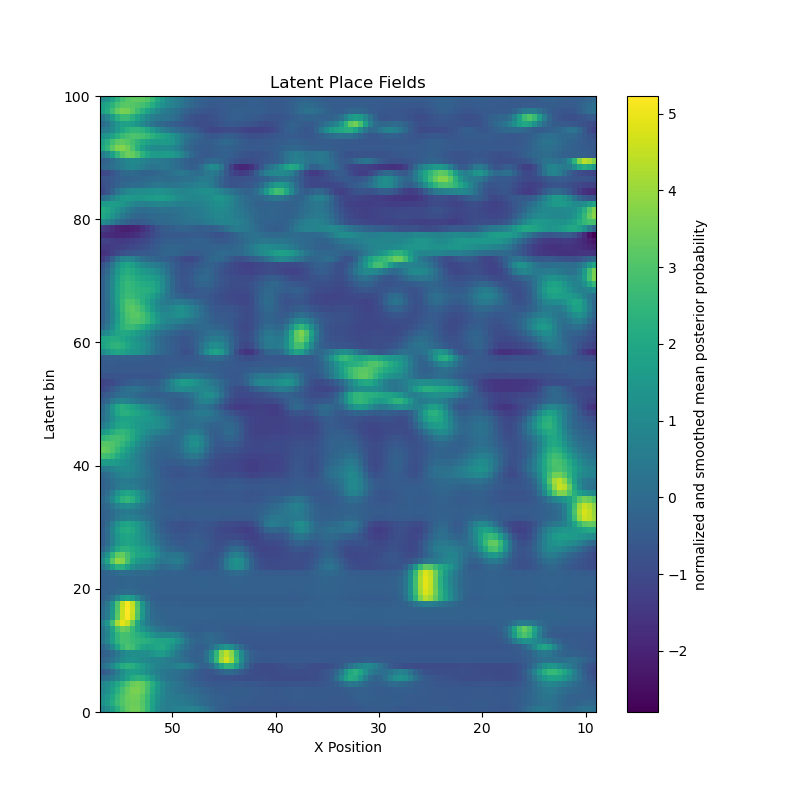

[70 79 80 81 82 71 30 89 88 31 34 33 32 38 37 36 35 39 40  6 46 47 96 78
 12 77 27 26 28 76 75 85 86 87 48 52 23 19 22 18 21 20 74 73 72 56 54 53
 55 51 50 95 57 60 61 59 84  9  8  7 83  5  4  3 94 63 99  2  1  0 65 93
 66 64 29 62 67 15 16 17 68 10 98 69 90 11 91 92 97 14 13 45 25 49 58 44
 24 41 43 42]


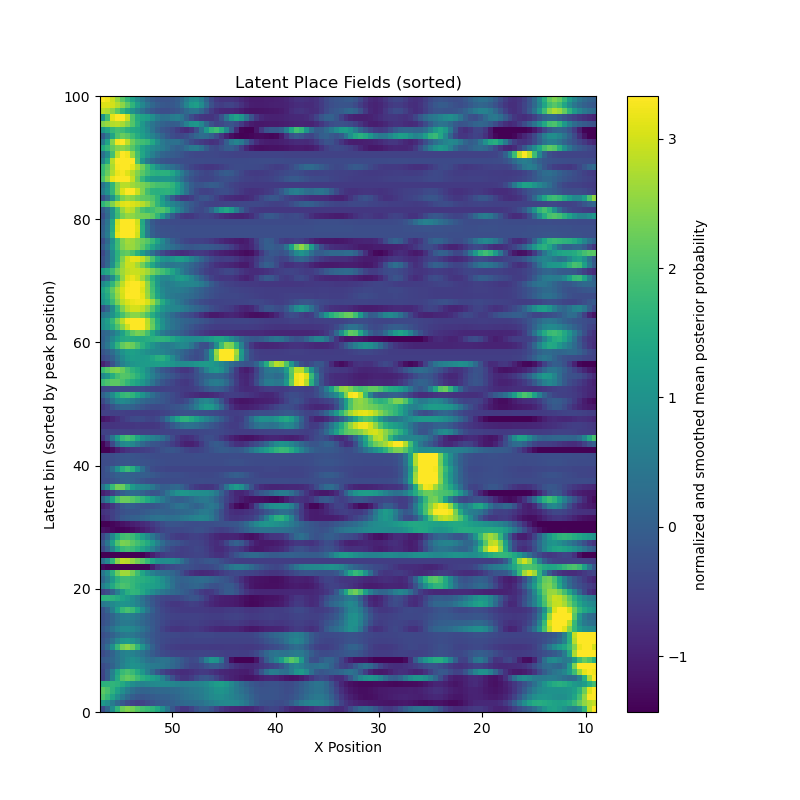

In [19]:
# building a speed threshold mask to identify time bins where the animal is moving vs stationary
SPEED_THRESHOLD = 0.03  # adjust this threshold based on the data

pos_smooth = gaussian_filter1d(pos, sigma=2)  # smooth the position for better speed estimation
speed = np.gradient(pos_smooth, tracking_timestamps)
speed = np.abs(gaussian_filter1d(speed, sigma=2))  # smooth the speed for better thresholding

plt.figure()
plt.hist(speed, bins=100, color='gray', alpha=0.7)
plt.axvline(SPEED_THRESHOLD, color='red', linestyle='--', label=f'Speed Threshold = {SPEED_THRESHOLD}')
plt.axvline(np.median(speed), color='blue', linestyle='--', label=f'Median Speed = {np.median(speed):.2f}')
plt.xlim(0, np.percentile(speed, 95))
plt.legend()
plt.show()



speed_mask = speed > SPEED_THRESHOLD



# making place fields for each latent bin
print(f"use_posterior shape: {posterior.shape}, pos_bin_indices shape: {pos_bin_indices.shape}")
latent_place_fields = np.zeros((N_LATENT_BINS, N_LATENT_BINS))
for current_position in range(N_LATENT_BINS):

    # getting the time_bins where the animal was in the current position bin
    time_bins_use = tracking_timestamps[(pos_bin_indices == current_position) & speed_mask]

    # getting the indices that correspond to these time_bins in the posterior
    indices_use = np.searchsorted(time_bins, time_bins_use)
  
    # getting the posterior probabilities for the current latent bin at these indices
    posterior_use = posterior[indices_use, :]

    # getting the mean posterior probability for each latent bin when the animal was in the current position bin
    latent_place_fields[current_position, :] = posterior_use.mean(axis=0)


plt.figure(figsize=(8, 8))
plt.imshow(latent_place_fields.T, aspect='auto', origin='lower', cmap='viridis', extent=[pos_bins[0], pos_bins[-1], 0, N_LATENT_BINS])
plt.colorbar(label='Mean posterior probability')
plt.xlabel('X Position')
plt.ylabel('Latent bin')
plt.title('Latent Place Fields')
plt.show()


# smooth and sort the place fields for better visualization
from scipy.ndimage import gaussian_filter1d
smoothed_fields = zscore(gaussian_filter1d(latent_place_fields, sigma=2, axis=0), axis=0)


plt.figure(figsize=(8, 8))
plt.imshow(smoothed_fields.T, aspect='auto', origin='lower', cmap='viridis', extent=[pos_bin_indices[0], pos_bin_indices[-1], 0, N_LATENT_BINS])
plt.colorbar(label='normalized and smoothed mean posterior probability')
plt.xlabel('X Position')
plt.ylabel('Latent bin')
plt.title('Latent Place Fields')
plt.show()


# sort the latent bins by their peak position
peak_positions = np.argmax(smoothed_fields, axis=0)
sorted_indices = np.argsort(peak_positions)
# reverse_direction
sorted_indices = sorted_indices[::-1]
print(sorted_indices)
plt.figure(figsize=(8, 8))
plt.imshow(smoothed_fields[:, sorted_indices].T, aspect='auto', origin='lower', cmap='viridis', extent=[pos_bin_indices[0], pos_bin_indices[-1], 0, N_LATENT_BINS], vmin = np.percentile(smoothed_fields, 1), vmax = np.percentile(smoothed_fields, 99))
plt.colorbar(label='normalized and smoothed mean posterior probability')
plt.xlabel('X Position')
plt.ylabel('Latent bin (sorted by peak position)')
plt.title('Latent Place Fields (sorted)')
plt.show()

